# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import argparse
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)

## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [ ]:
# editing the args 
args.dataset = 'duffing_oscillator'
args.folder = 'duffing_oscillator_continuous'
args.time_steps = 101
args.prediction_length = 100
args.max_time = 10
args.bottleneck  = 50
args.decoder_loss_weight = 1
# args.num_combinations
# args.num_samples
# args.time_steps
# args.max_timex
# args.lr
# args.batch_size
# args.decoder_loss_weight
# args.bottleneck
# args.encoder_hidden_layers


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [26]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [27]:
# Configuration for data handler
config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize and prepare data
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get input size for model
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 6000/6000 [00:00<00:00, 40779.14it/s]

the shape of the data is torch.Size([6000, 101, 2])
Processing dataset: duffing_oscillator
train_idx: 4800, val_idx: 5400
Processed data shapes - Train: torch.Size([4800, 101, 2]), Val: torch.Size([600, 101, 2]), Test: torch.Size([600, 101, 2])



/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:130: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Testing Multiple Repos/bio-koopman-autoencoder/data_handler.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().

## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [28]:
# Define autoencoder and Koopman operator
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

# Combine into a model
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [29]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.03M
Total params: 33.35k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=2, out_features=100, bias=True)
        (1): ReLU()
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): ReLU()
        (4): Linear(in_features=100, out_features=50, bias=True)
      )
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=50, out_features=100, bias=True)
        (1): ReLU()
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): ReLU()
        (4): Linear(in_features=100, out_features=2, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=50, out_features=50, bias=False)
  )
)
***************************


## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [30]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

## Training

Train the model using the `Trainer` class with the specified data loaders.

In [31]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)
trainer.train_KoopmanAE()

Using the CPU


Training Epochs:  20%|██        | 20/100 [00:30<02:00,  1.51s/it]

Epoch 20/100
Training - Recon Loss: 1.451759e-04, Linear Loss: 7.718986e-05, Pred Loss: 3.418260e-03, Total Loss: 3.640626e-03
Validation - Recon Loss: 1.741231e-04, Linear Loss: 7.506205e-05, Pred Loss: 3.524289e-03, Total Loss: 3.773475e-03


Training Epochs:  40%|████      | 40/100 [01:01<01:31,  1.52s/it]

Epoch 40/100
Training - Recon Loss: 1.321640e-05, Linear Loss: 8.058638e-05, Pred Loss: 1.744561e-03, Total Loss: 1.838364e-03
Validation - Recon Loss: 1.151007e-05, Linear Loss: 7.729228e-05, Pred Loss: 1.720195e-03, Total Loss: 1.808998e-03


...

Training Epochs:  80%|████████  | 80/100 [02:05<00:31,  1.60s/it]

Epoch 80/100
Training - Recon Loss: 1.076889e-05, Linear Loss: 6.921553e-05, Pred Loss: 1.291164e-03, Total Loss: 1.371149e-03
Validation - Recon Loss: 8.693831e-06, Linear Loss: 6.814729e-05, Pred Loss: 1.250212e-03, Total Loss: 1.327053e-03


Training Epochs: 100%|██████████| 100/100 [02:38<00:00,  1.59s/it]

Epoch 100/100
Training - Recon Loss: 7.691989e-06, Linear Loss: 7.158192e-05, Pred Loss: 9.745975e-04, Total Loss: 1.053871e-03
Validation - Recon Loss: 7.397738e-06, Linear Loss: 6.973485e-05, Pred Loss: 9.858590e-04, Total Loss: 1.062992e-03


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=2, out_features=100, bias=True)
         (1): ReLU()
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): ReLU()
         (4): Linear(in_features=100, out_features=50, bias=True)
       )
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=50, out_features=100, bias=True)
         (1): ReLU()
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): ReLU()
         (4): Linear(in_features=100, out_features=2, bias=True)
       )
     )
   )
   (knet): Knet(
     (net): Linear(in_features=50, out_features=50, bias=False)
   )
 ),
 AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 4e-05
     maximize: False
     weight_decay: 0.0
 ),
 {'recon_loss_tr': [0.0092

In [32]:
# test the model
trainer.test_KoopmanAE(test_loader)

Test - Recon Loss: 7.724748e-06, Linear Loss: 7.127877e-05, Pred Loss: 9.992129e-04, Total Loss: 1.078216e-03


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

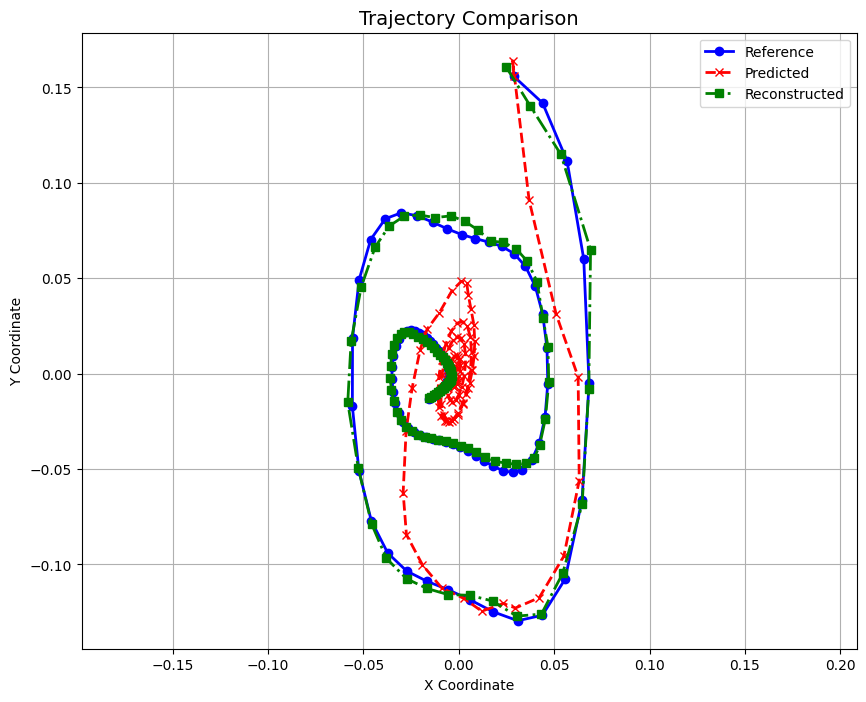

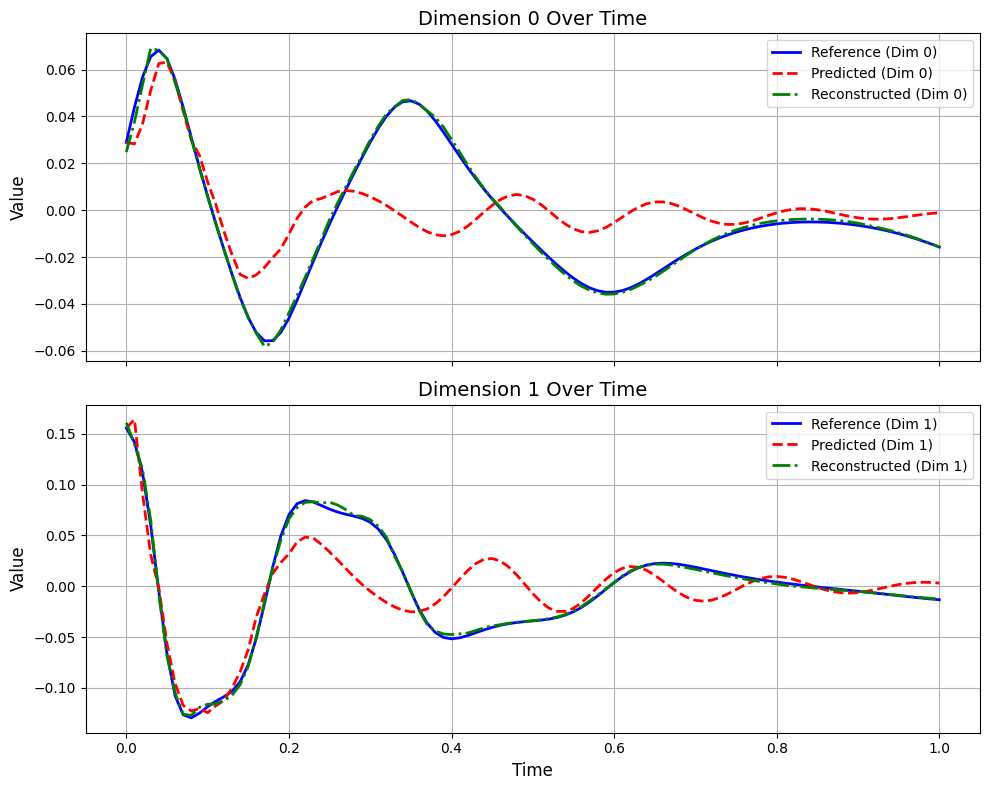

In [33]:
# Get a test sample
traj = preprocessed_data["Xtest"][5].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj, predicted_traj, reconstructed_traj, folder_path=folder_path)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path)

## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[ 0.9079914 +0.32260853j  0.9079914 -0.32260853j  0.86331224+0.38131067j
  0.86331224-0.38131067j  0.7674355 -0.45564875j  0.7674355 +0.45564875j
  0.3979552 +0.j          0.38752338-0.27190587j  0.38752338+0.27190587j
  0.3586069 +0.j          0.28624564+0.280969j    0.28624564-0.280969j
  0.17072606-0.20853828j  0.17072606+0.20853828j  0.1439971 +0.0669472j
  0.1439971 -0.0669472j   0.13765016-0.5293905j   0.13765016+0.5293905j
  0.11086704+0.j          0.0509179 -0.3342016j   0.0509179 +0.3342016j
  0.01253044+0.20457487j  0.01253044-0.20457487j  0.00106092+0.09376918j
  0.00106092-0.09376918j -0.09368815+0.23631303j -0.09368815-0.23631303j
 -0.09575114-0.04468786j -0.09575114+0.04468786j -0.10072161-0.5190696j
 -0.10072161+0.5190696j  -0.10083844+0.33291006j -0.10083844-0.33291006j
 -0.14998183-0.18857643j -0.14998183+0.18857643j -0.20972012+0.j
 -0.21913376-0.41886526j -0.21913376+0.41886526j -0.25437963+0.j
 -0.26386744+0.3227848j  -0.26386744-0.3227848j  -0.34379458

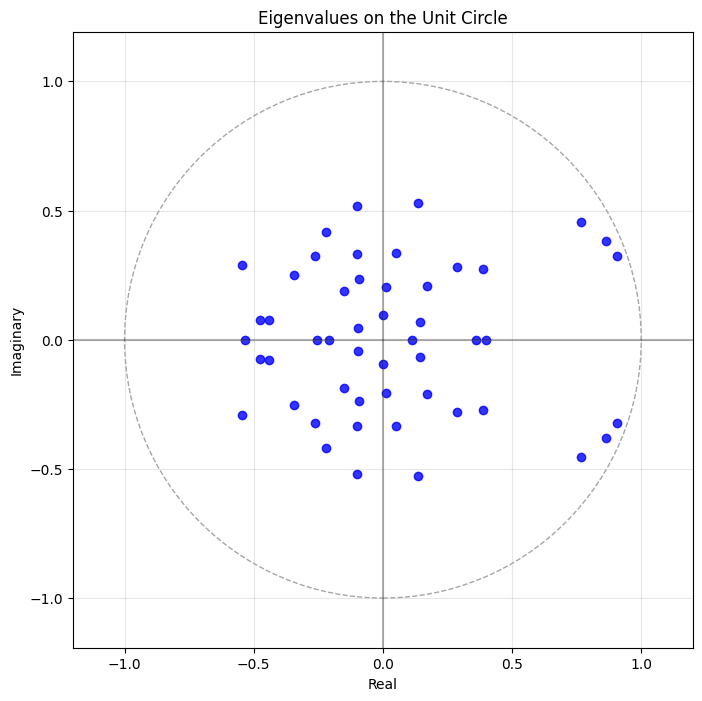

In [34]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")

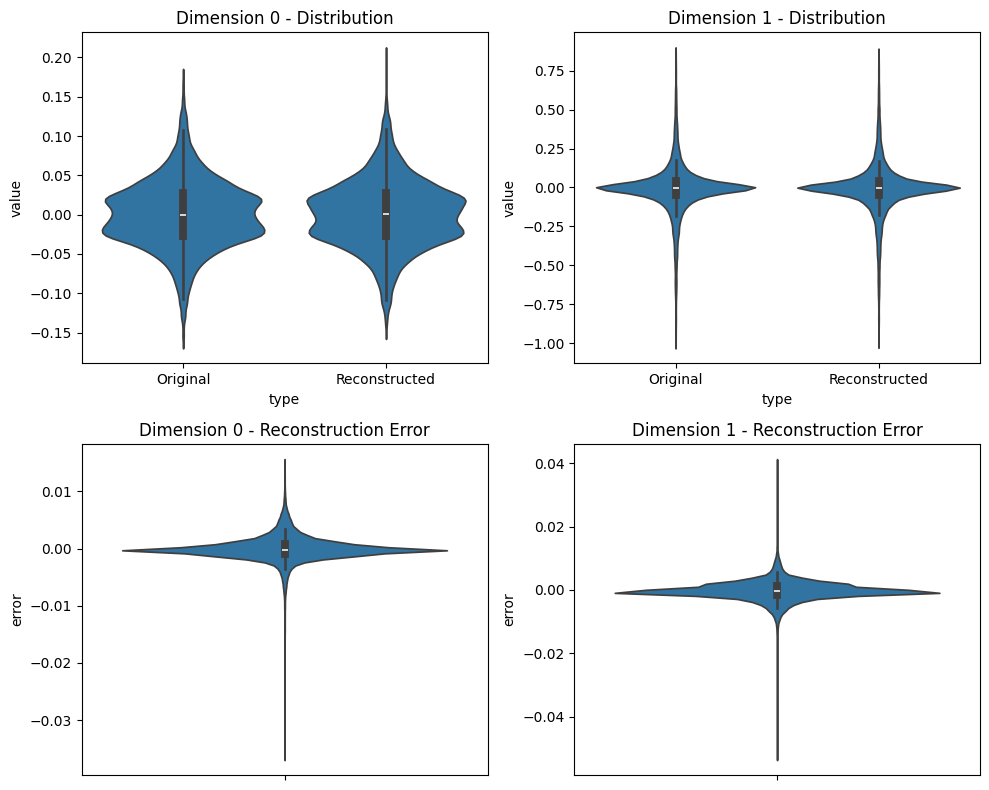

In [35]:
violin_plot(model, preprocessed_data["Xtest"], device, folder_path)

## Creating Residual Dataset

In [36]:
# print the first sample in the train loader
print(next(iter(train_loader))[0][0])

tensor([[ 8.6943e-02,  1.6971e-01],
        [ 9.5318e-02, -9.1262e-03],
        [ 8.5542e-02, -1.7583e-01],
        [ 6.3070e-02, -2.5867e-01],
        [ 3.6132e-02, -2.7259e-01],
        [ 9.3301e-03, -2.6226e-01],
        [-1.6327e-02, -2.5125e-01],
        [-4.0830e-02, -2.3689e-01],
        [-6.2888e-02, -1.9789e-01],
        [-7.8796e-02, -1.1167e-01],
        [-8.3890e-02,  1.2823e-02],
        [-7.6594e-02,  1.2684e-01],
        [-6.0246e-02,  1.9090e-01],
        [-3.9981e-02,  2.0862e-01],
        [-1.9248e-02,  2.0426e-01],
        [ 7.5184e-04,  1.9588e-01],
        [ 1.9986e-02,  1.8889e-01],
        [ 3.8415e-02,  1.7819e-01],
        [ 5.5094e-02,  1.5155e-01],
        [ 6.7785e-02,  9.7219e-02],
        [ 7.3669e-02,  1.7638e-02],
        [ 7.1222e-02, -6.4521e-02],
        [ 6.1569e-02, -1.2328e-01],
        [ 4.7638e-02, -1.5049e-01],
        [ 3.2228e-02, -1.5505e-01],
        [ 1.6955e-02, -1.4960e-01],
        [ 2.3572e-03, -1.4249e-01],
        [-1.1590e-02, -1.366

In [53]:
def create_residual_dataset(dataloader, model, trainer, device):
    """
    Create a residual dataset from the difference between true and predicted trajectories.
    
    Args:
        dataloader: DataLoader containing time series data
        model: Trained model
        trainer: Trainer object with predict_new function
        device: Device for computation
        
    Returns:
        residual_trajectories: List of residual trajectories (true - predicted)
    """
    model.eval()
    residual_trajectories = []
    
    with torch.no_grad():
        for batch in dataloader:
            trajectories = batch[0].to(device)  # Shape: [batch_size, time_steps, features]
            
            for traj in trajectories:
                # Get true trajectory
                true_traj = traj  # Shape: [time_steps, features]
                
                # Get initial condition
                initial_condition = traj[0]  # Shape: [features]
                
                # Predict trajectory using initial condition
                predicted_traj = trainer.predict_new(X0=initial_condition, steps=len(true_traj)-1)
                
                # Ensure shapes match for subtraction
                if len(predicted_traj) < len(true_traj):
                    # Handle case where prediction has fewer steps
                    predicted_traj = torch.cat([initial_condition.unsqueeze(0), predicted_traj], dim=0)
                
                # Calculate residual: true - predicted
                residual = true_traj - predicted_traj

                residual[0] = true_traj[0]
                
                residual_trajectories.append(residual.cpu())
    
    return residual_trajectories

In [54]:
# Create residual datasets
train_residuals = create_residual_dataset(train_loader, model, trainer, device)
val_residuals = create_residual_dataset(val_loader, model, trainer, device)

# Convert to tensors
train_residual_tensor = torch.stack(train_residuals)
val_residual_tensor = torch.stack(val_residuals)

# Create new PyTorch datasets
from torch.utils.data import TensorDataset, DataLoader

train_residual_dataset = TensorDataset(train_residual_tensor)
val_residual_dataset = TensorDataset(val_residual_tensor)

# Create new dataloaders
train_residual_loader = DataLoader(
    train_residual_dataset, 
    batch_size=train_loader.batch_size,
    shuffle=True
)

val_residual_loader = DataLoader(
    val_residual_dataset, 
    batch_size=test_loader.batch_size,
    shuffle=False
)

print(f"Created residual datasets - Train: {len(train_residual_dataset)}, Val: {len(val_residual_dataset)}")

# Example of accessing a residual trajectory
sample_residual = next(iter(train_residual_loader))[0][0]
print(f"Sample residual trajectory shape: {sample_residual.shape}")

Created residual datasets - Train: 4800, Val: 600
Sample residual trajectory shape: torch.Size([101, 2])


In [57]:
print(len(train_residual_loader))
print(len(val_residual_loader))

38
5


## Residual Model

In [97]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers)
        # add sequential layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x, hidden):
        """
        x: input at current time step with shape (1, batch, input_size)
        hidden: previous hidden state (tuple for LSTM)
        """
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

In [98]:
import torch.optim as optim
import random
# ---------------------------
# Training with Scheduled Sampling
# ---------------------------
def train(model, dataloader, num_epochs, device):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    teacher_forcing_ratio = 1.0  # Start with full teacher forcing
    decay_rate = 0.95            # Decay teacher forcing ratio every epoch

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for batch in dataloader:
            # Each batch has shape: (batch, T, features)
            # Transpose to (T, batch, features) for sequential processing
            batch = batch[0].transpose(0, 1).to(device)
            optimizer.zero_grad()
            
            # Use the first T-1 time steps as inputs and the next T-1 as targets.
            input_seq = batch[:-1]    # shape: (T-1, batch, input_size)
            target_seq = batch[1:]    # shape: (T-1, batch, output_size)
            seq_len = target_seq.shape[0]
            
            # Initialize hidden state to None (LSTM will initialize zeros internally)
            hidden = None
            
            # Start with the first input of the sequence
            input_t = input_seq[0].unsqueeze(0)  # shape: (1, batch, input_size)
            outputs = []
            
            # Roll through the sequence with scheduled sampling
            for t in range(seq_len):
                out, hidden = model(input_t, hidden)
                outputs.append(out)
                
                # Scheduled sampling: decide whether to use teacher forcing
                if random.random() < teacher_forcing_ratio:
                    input_t = target_seq[t].unsqueeze(0)  # use ground truth
                else:
                    input_t = out  # use model's own prediction
            
            # Concatenate outputs: shape becomes (T-1, batch, output_size)
            outputs = torch.cat(outputs, dim=0)
            loss = criterion(outputs, target_seq)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        # Decay teacher forcing ratio after each epoch
        teacher_forcing_ratio *= decay_rate
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Teacher Forcing Ratio: {teacher_forcing_ratio:.4f}")

In [99]:
# LSTM model parameters
input_size = 2    # Lorenz system has 2 state variables
hidden_size = 64  # hidden layer size
output_size = 2   # predicting next state 
num_layers = 1
model = LSTMModel(input_size, hidden_size, output_size, num_layers).to(device)

num_epochs = 100
train(model, train_residual_loader, num_epochs, device)

# Visualize a sample trajectory and compare the model prediction with the ground truth.
# prediction_steps sets how many time steps to predict.

Epoch 1, Loss: 0.0699, Teacher Forcing Ratio: 0.9500
Epoch 2, Loss: 0.0339, Teacher Forcing Ratio: 0.9025
Epoch 3, Loss: 0.0264, Teacher Forcing Ratio: 0.8574
Epoch 4, Loss: 0.0151, Teacher Forcing Ratio: 0.8145
Epoch 5, Loss: 0.0092, Teacher Forcing Ratio: 0.7738
Epoch 6, Loss: 0.0080, Teacher Forcing Ratio: 0.7351
Epoch 7, Loss: 0.0075, Teacher Forcing Ratio: 0.6983
Epoch 8, Loss: 0.0075, Teacher Forcing Ratio: 0.6634
Epoch 9, Loss: 0.0075, Teacher Forcing Ratio: 0.6302
Epoch 10, Loss: 0.0079, Teacher Forcing Ratio: 0.5987
Epoch 11, Loss: 0.0080, Teacher Forcing Ratio: 0.5688
Epoch 12, Loss: 0.0086, Teacher Forcing Ratio: 0.5404
Epoch 13, Loss: 0.0083, Teacher Forcing Ratio: 0.5133
Epoch 14, Loss: 0.0089, Teacher Forcing Ratio: 0.4877
Epoch 15, Loss: 0.0088, Teacher Forcing Ratio: 0.4633
Epoch 16, Loss: 0.0088, Teacher Forcing Ratio: 0.4401
Epoch 17, Loss: 0.0092, Teacher Forcing Ratio: 0.4181
Epoch 18, Loss: 0.0116, Teacher Forcing Ratio: 0.3972
Epoch 19, Loss: 0.0105, Teacher Forci

In [100]:
# ---------------------------
# Visualization of Prediction vs Ground Truth
# ---------------------------
def visualize_prediction(model, dataset, device, index=0, prediction_steps=100):
    """
    Visualizes a sample Lorenz trajectory (ground truth) and the model's prediction.
    The model prediction is generated in an autoregressive manner.
    """
    model.eval()
    # Select a trajectory from the dataset
    traj = dataset[index][0]  # shape: (T, features)
    print(traj)
   
    traj = traj.to(device)
    T = traj.shape[0]
    
    # Use the first 'prediction_steps' points from the trajectory as ground truth
    ground_truth = traj[:prediction_steps].cpu().detach().numpy()
    
    # Generate prediction starting from the initial condition
    with torch.no_grad():
        hidden = None
        # Ensure the initial input is squeezed properly to shape (1, 1, features)
        input_t = traj[0].unsqueeze(0).unsqueeze(0)  
        predictions = [input_t.squeeze(0).squeeze(0).cpu().numpy()]
        
        for t in range(1, prediction_steps):
            out, hidden = model(input_t, hidden)
            # Squeeze to get shape (features,)
            predictions.append(out.squeeze(0).squeeze(0).cpu().numpy())
            input_t = out

    predictions = np.array(predictions)

    # Plot time-series for each variable (x, y)
    t_axis = np.arange(prediction_steps)
    plt.figure(figsize=(15, 4))
    for i, label in enumerate(['x', 'y']):
        plt.subplot(1, 3, i+1)
        plt.plot(t_axis, ground_truth[:, i], label='Ground Truth', color='blue')
        plt.plot(t_axis, predictions[:, i], label='Prediction', linestyle='--', color='red')
        plt.title(f'{label} vs Time')
        plt.xlabel('Time Step')
        plt.ylabel(label)
        plt.legend()
    plt.tight_layout()
    plt.show()

tensor([[ 2.9982e-02,  7.0017e-02],
        [ 1.3859e-02, -3.6618e-02],
        [ 1.7275e-02,  4.8369e-03],
        [ 6.2038e-03, -1.3977e-02],
        [ 2.6566e-03, -5.2018e-03],
        [ 3.2662e-03,  6.1838e-03],
        [ 9.9708e-03,  7.4711e-03],
        [ 1.2577e-02, -7.7410e-03],
        [ 1.5122e-02, -1.8475e-02],
        [ 1.7656e-02, -2.3447e-02],
        [ 1.8817e-02, -1.6458e-02],
        [ 1.8720e-02, -1.1217e-02],
        [ 1.7488e-02, -8.6049e-03],
        [ 1.5326e-02, -9.8498e-03],
        [ 1.2621e-02, -1.2536e-02],
        [ 9.6094e-03, -1.6417e-02],
        [ 6.5388e-03, -2.0980e-02],
        [ 2.8498e-03, -2.5998e-02],
        [-1.3548e-03, -3.0747e-02],
        [-5.9060e-03, -3.4563e-02],
        [-1.0587e-02, -3.6939e-02],
        [-1.5164e-02, -3.7606e-02],
        [-1.9433e-02, -3.6565e-02],
        [-2.3249e-02, -3.4062e-02],
        [-2.6541e-02, -3.0493e-02],
        [-2.9309e-02, -2.6284e-02],
        [-3.1591e-02, -2.1776e-02],
        [-3.3429e-02, -1.713

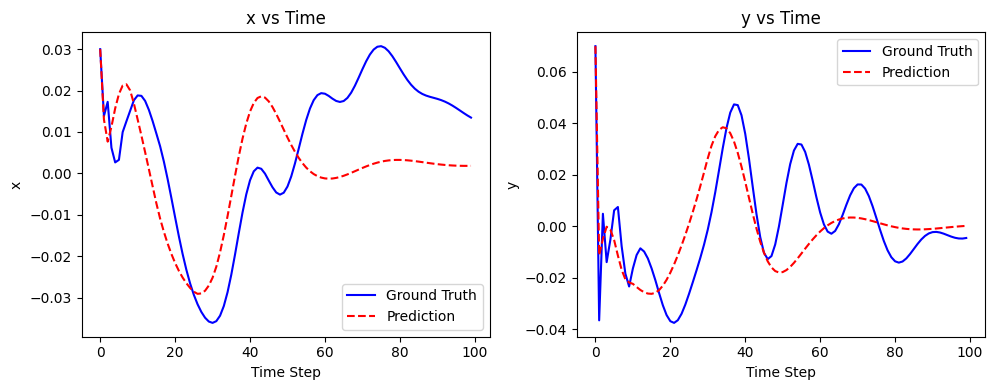

In [101]:
visualize_prediction(model, val_residual_dataset, device, index=0, prediction_steps=100)